# Project 6: Wine Quality Prediction
**Oasis Infobyte - Level 2**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
print('Libraries ready!')

Libraries ready!


## Step 1: Generate Wine Dataset

In [ ]:
np.random.seed(42)
n = 1000
alcohol = np.random.uniform(8, 15, n)
volatile_acidity = np.random.uniform(0.1, 1.6, n)
citric_acid = np.random.uniform(0, 1, n)
sulphates = np.random.uniform(0.3, 2.0, n)
chlorides = np.random.uniform(0.01, 0.2, n)
fixed_acidity = np.random.uniform(4.5, 16, n)
residual_sugar = np.random.uniform(1, 15, n)
pH = np.random.uniform(2.7, 4.2, n)
density = np.random.uniform(0.990, 1.004, n)
free_SO2 = np.random.uniform(1, 72, n)
total_SO2 = np.random.uniform(6, 289, n)

score = alcohol*0.4 - volatile_acidity*2 + citric_acid*1.5 + sulphates*0.8 - chlorides*3 + np.random.normal(0,0.5,n)
quality = pd.cut(score, bins=3, labels=['Low','Medium','High'])

df = pd.DataFrame({
    'fixed_acidity':np.round(fixed_acidity,2),
    'volatile_acidity':np.round(volatile_acidity,3),
    'citric_acid':np.round(citric_acid,3),
    'residual_sugar':np.round(residual_sugar,2),
    'chlorides':np.round(chlorides,4),
    'free_sulfur_dioxide':np.round(free_SO2,1),
    'total_sulfur_dioxide':np.round(total_SO2,1),
    'density':np.round(density,5),
    'pH':np.round(pH,2),
    'sulphates':np.round(sulphates,3),
    'alcohol':np.round(alcohol,2),
    'quality':quality
})
print('Shape:', df.shape)
df['quality'].value_counts()

Shape: (1000, 12)


,count
quality,
Medium,677
Low,190
High,133


## Step 2: EDA - Feature Distributions

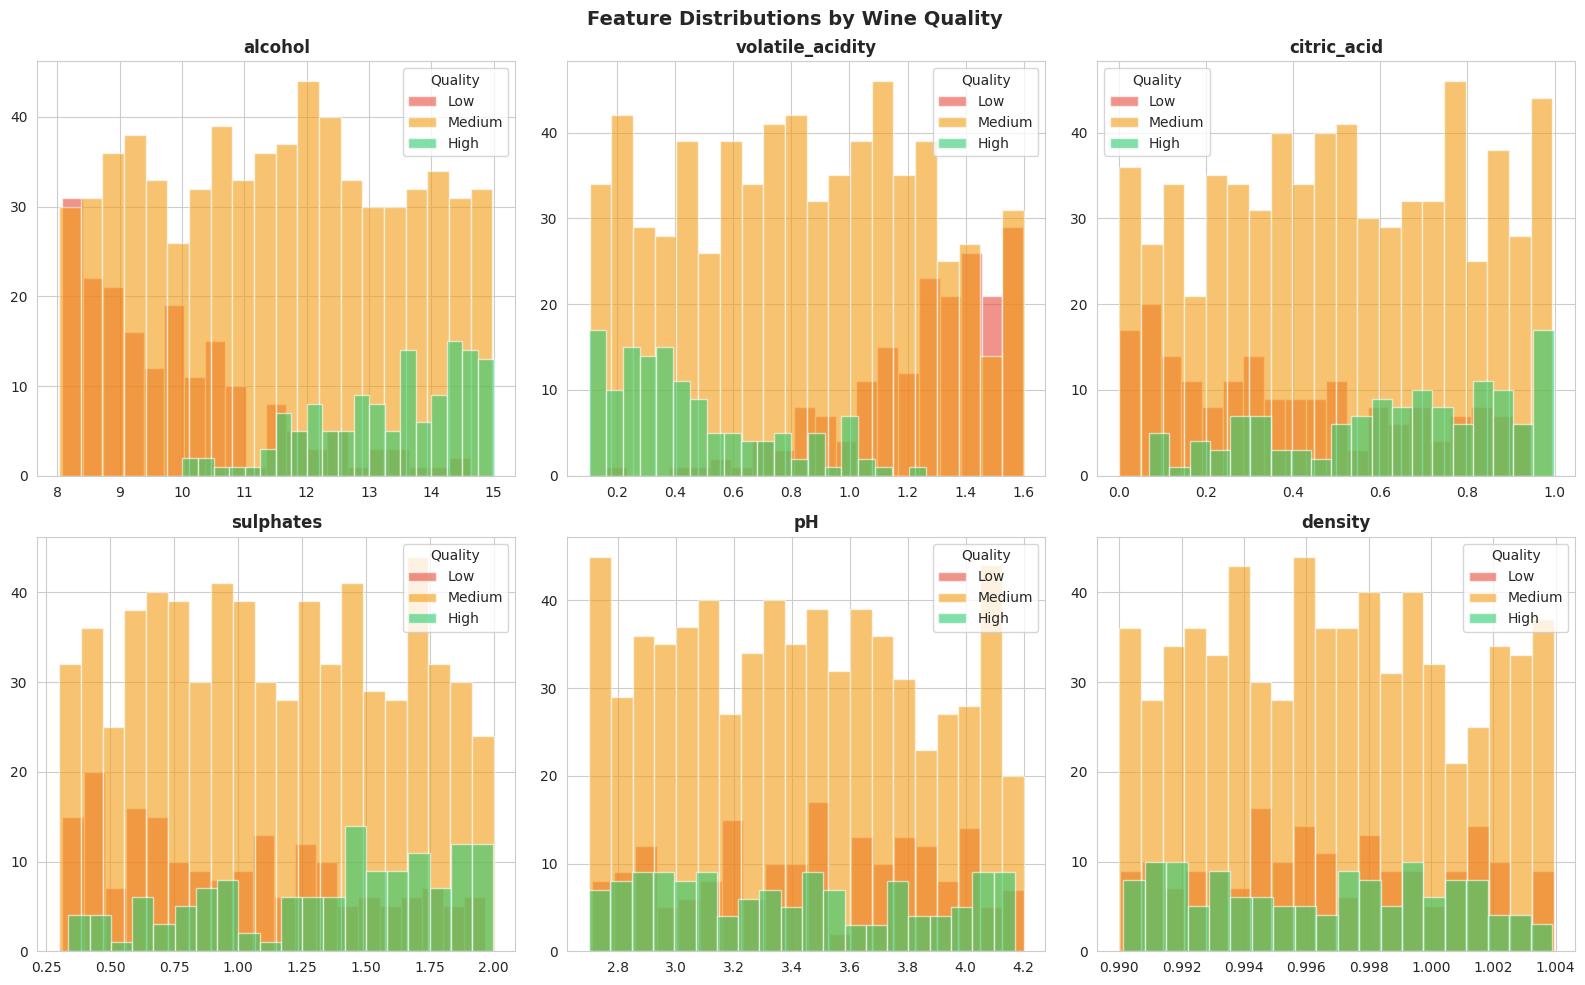

In [3]:
fig, axes = plt.subplots(2,3,figsize=(16,10))
colors = {'Low':'#E74C3C','Medium':'#F39C12','High':'#2ECC71'}
for ax, feat in zip(axes.flatten(), ['alcohol','volatile_acidity','citric_acid','sulphates','pH','density']):
    for q, color in colors.items():
        ax.hist(df[df['quality']==q][feat], bins=20, alpha=0.6, color=color, label=q)
    ax.set_title(feat, fontweight='bold'); ax.legend(title='Quality')
plt.suptitle('Feature Distributions by Wine Quality', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

## Step 3: Correlation Heatmap

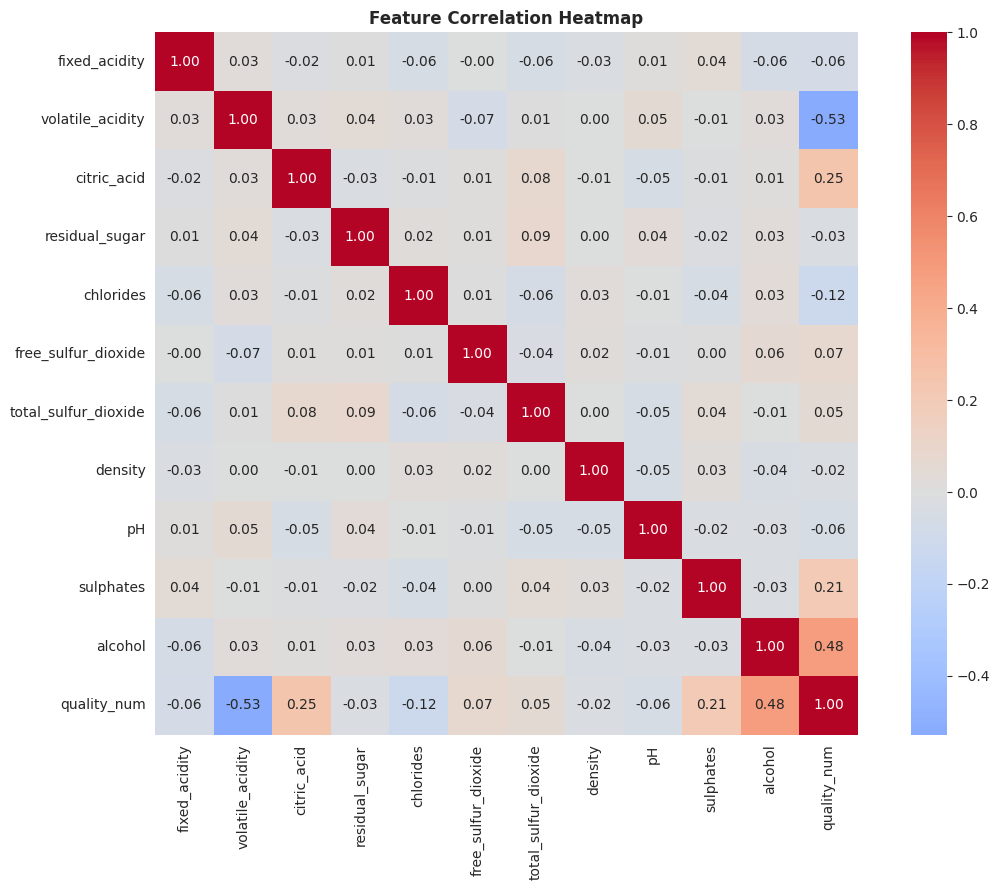

In [4]:
num_df = df.select_dtypes(include=[np.number]).copy()
num_df['quality_num'] = df['quality'].map({'Low':1,'Medium':2,'High':3})
plt.figure(figsize=(12,9))
sns.heatmap(num_df.corr(), annot=True, fmt='.2f', cmap='coolwarm', square=True, center=0)
plt.title('Feature Correlation Heatmap', fontweight='bold')
plt.tight_layout(); plt.show()

## Step 4: Train 3 Models

In [5]:
feature_cols = ['fixed_acidity','volatile_acidity','citric_acid','residual_sugar',
                'chlorides','free_sulfur_dioxide','total_sulfur_dioxide',
                'density','pH','sulphates','alcohol']
X = df[feature_cols]; y = df['quality']
X_train,X_test,y_train,y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()
X_tr = scaler.fit_transform(X_train); X_te = scaler.transform(X_test)

models = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'SGD Classifier': SGDClassifier(random_state=42, max_iter=1000),
    'Support Vector Classifier': SVC(kernel='rbf', random_state=42)
}
results = {}
for name, model in models.items():
    model.fit(X_tr, y_train)
    preds = model.predict(X_te)
    acc = accuracy_score(y_test, preds)
    results[name] = {'preds':preds,'acc':acc}
    print(f'{name}: {acc:.4f}')

Random Forest: 0.8150
SGD Classifier: 0.8200
Support Vector Classifier: 0.8350


## Step 5: Model Comparison & Feature Importance

Best: Support Vector Classifier
              precision    recall  f1-score   support

        High       0.78      0.52      0.62        27
         Low       0.87      0.68      0.76        38
      Medium       0.84      0.94      0.89       135

    accuracy                           0.83       200
   macro avg       0.83      0.71      0.76       200
weighted avg       0.83      0.83      0.83       200



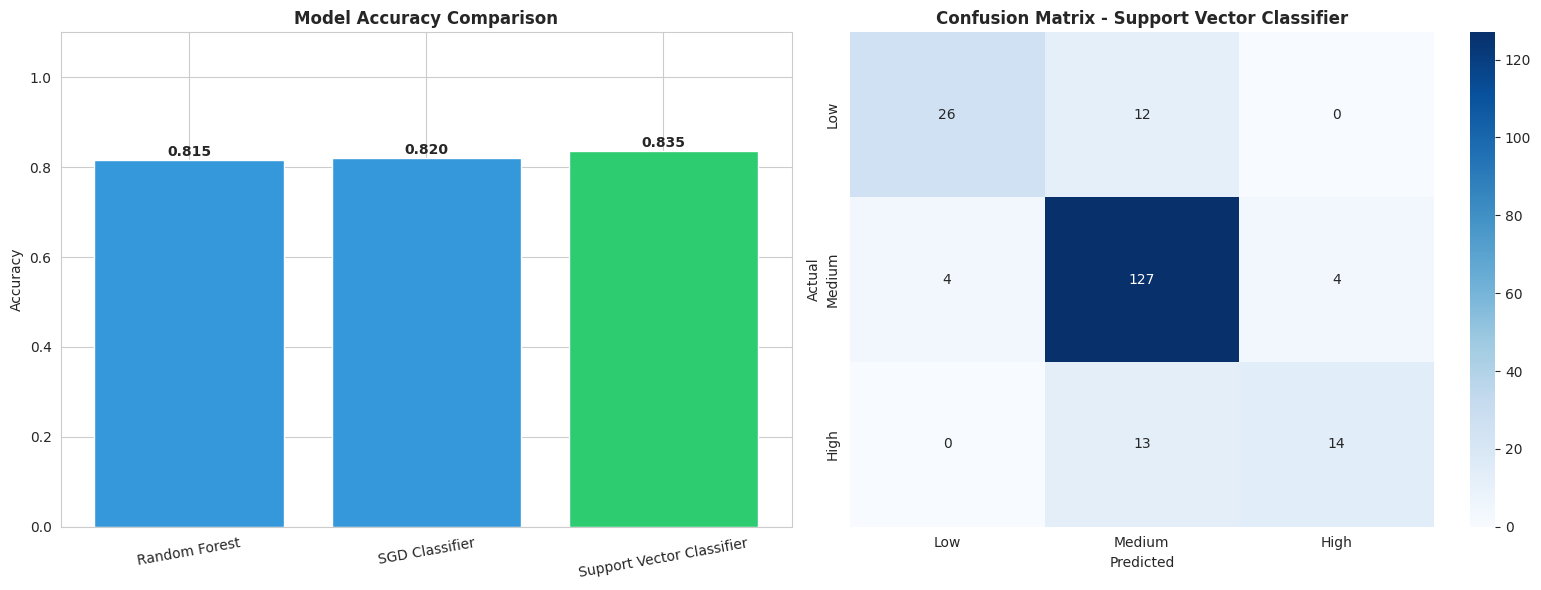

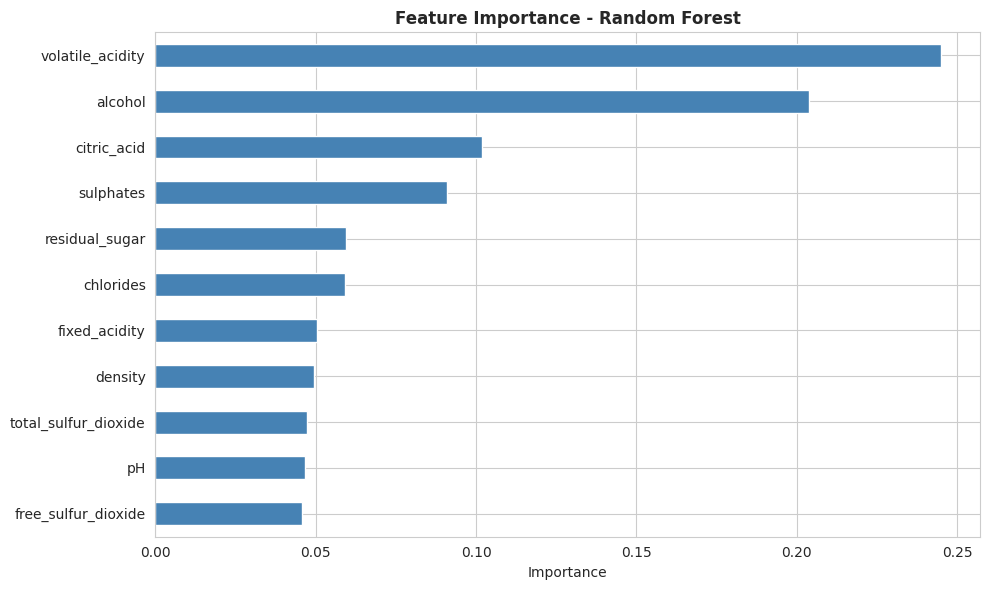

In [6]:
best = max(results, key=lambda x: results[x]['acc'])
print(f'Best: {best}')
print(classification_report(y_test, results[best]['preds']))

fig, axes = plt.subplots(1,2,figsize=(16,6))
names = list(results.keys()); accs = [results[n]['acc'] for n in names]
bar_colors = ['#2ECC71' if n==best else '#3498DB' for n in names]
axes[0].bar(names, accs, color=bar_colors)
axes[0].set_title('Model Accuracy Comparison', fontweight='bold')
axes[0].set_ylabel('Accuracy'); axes[0].set_ylim(0,1.1)
for i,a in enumerate(accs): axes[0].text(i, a+0.01, f'{a:.3f}', ha='center', fontweight='bold')
axes[0].tick_params(axis='x', rotation=10)

cm = confusion_matrix(y_test, results[best]['preds'], labels=['Low','Medium','High'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Low','Medium','High'], yticklabels=['Low','Medium','High'])
axes[1].set_title(f'Confusion Matrix - {best}', fontweight='bold')
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('Actual')
plt.tight_layout(); plt.show()

rf = models['Random Forest']
imp = pd.Series(rf.feature_importances_, index=feature_cols).sort_values()
plt.figure(figsize=(10,6))
imp.plot(kind='barh', color='steelblue')
plt.title('Feature Importance - Random Forest', fontweight='bold')
plt.xlabel('Importance'); plt.tight_layout(); plt.show()